### seqFISH Mouse Organogenesis datasets

In [1]:
import os
import pandas as pd
import numpy as np

os.chdir('/pri_exthome/zhouwg/project/Garfield')
os.getcwd()

'/pri_exthome/zhouwg/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
import numpy as np
import pandas as pd
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

In [3]:
## 准备数据集
# Define paths
st_data_folder_path = "/pri_exthome/zhouwg/project/spatial_data" # spatially resolved transcriptomics data
st_data_silver_folder_path = f"{st_data_folder_path}/silver"
st_data_gold_folder_path = f"{st_data_folder_path}/gold"
# Create required directories
os.makedirs(st_data_silver_folder_path, exist_ok=True)
os.makedirs(st_data_gold_folder_path, exist_ok=True)

dataset = "seqfish_mouse_organogenesis"
cell_type_key = "celltype_mapped_refined"

# Read preprocessed data
adata = sc.read_h5ad(f"{st_data_silver_folder_path}/{dataset}.h5ad")

# Filter low quality cells
adata = adata[adata.obs["celltype_mapped_refined"] != "Low quality"]

# Format adata
adata.obsm["spatial"] = np.column_stack((adata.obs.x, adata.obs.y))
adata.obs.drop(["x", "y"], axis=1, inplace=True)
adata.X = adata.X.astype(np.float32)
adata.layers["counts"] = adata.layers["counts"].astype(np.float32)

# Add sample & batch columns
adata.obs.loc[adata.obs.index.str.contains("embryo1"), "sample"] = "embryo1"
adata.obs.loc[adata.obs.index.str.contains("embryo2"), "sample"] = "embryo2"
adata.obs.loc[adata.obs.index.str.contains("embryo3"), "sample"] = "embryo3"

adata.obs.loc[adata.obs.index.str.startswith("embryo1") &
              adata.obs.index.str.endswith("z2"), "batch"] = "embryo1_z2"
adata.obs.loc[adata.obs.index.str.startswith("embryo1") &
              adata.obs.index.str.endswith("z5"), "batch"] = "embryo1_z5"
adata.obs.loc[adata.obs.index.str.startswith("embryo2") &
              adata.obs.index.str.endswith("z2"), "batch"] = "embryo2_z2"
adata.obs.loc[adata.obs.index.str.startswith("embryo2") &
              adata.obs.index.str.endswith("z5"), "batch"] = "embryo2_z5"
adata.obs.loc[adata.obs.index.str.startswith("embryo3") &
              adata.obs.index.str.endswith("z2"), "batch"] = "embryo3_z2"
adata.obs.loc[adata.obs.index.str.startswith("embryo3") &
              adata.obs.index.str.endswith("z5"), "batch"] = "embryo3_z5"

# Write adata to disk separated by batches
batch_indeces = list(np.arange(6) + 1)
batches = ["embryo1_z2",
           "embryo1_z5",
           "embryo2_z2",
           "embryo2_z5",
           "embryo3_z2",
           "embryo3_z5"]

for batch_idx, batch in zip(batch_indeces, batches):
    adata_batch = adata[adata.obs["batch"] == batch]
    adata_batch.write(f"{st_data_gold_folder_path}/{dataset}_batch{batch_idx}.h5ad")

In [4]:
# Load data
dataset = "seqfish_mouse_organogenesis"
cell_type_key = "celltype_mapped_refined"

adata_list = []
batch_indeces = list(np.arange(6) + 1)
batches = ["embryo1_z2",
           "embryo1_z5",
           "embryo2_z2",
           "embryo2_z5",
           "embryo3_z2",
           "embryo3_z5"]

for batch_idx, batch in zip(batch_indeces, batches):
    adata = sc.read_h5ad(f"{st_data_gold_folder_path}/{dataset}_batch{batch_idx}.h5ad")
    adata.var_names_make_unique(join="++")
    # make spot name unique
    # adata.obs_names = [x+'_'+batch for x in adata.obs_names]
    adata_list.append(adata)

In [5]:
import anndata as ad

adata_concat = ad.concat(adata_list, label="slice_name", keys=batches)
adata_concat

AnnData object with n_obs × n_vars = 52568 × 351
    obs: 'Area', 'celltype_mapped_refined', 'sample', 'batch', 'slice_name'
    obsm: 'spatial'
    layers: 'counts'

In [6]:
# check the batch information of this dataset
adata_concat.obs['batch'].value_counts()

batch
embryo3_z2    11169
embryo1_z2    10150
embryo3_z5     9408
embryo2_z2     7661
embryo1_z5     7656
embryo2_z5     6524
Name: count, dtype: int64

In [7]:
# Ensure adata.X is counts.
adata_concat.X = adata_concat.layers['counts'].copy()
adata_concat.X = adata_concat.X.toarray().astype(np.float32)
adata_concat.X.max()

141.0

## Integrating spatially resolved transcriptomics data using Garfield

In [8]:
# set workdir
workdir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_embryo'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=adata_concat,
    profile='spatial',
    data_type='single-modal',
    sample_col='batch',
    weight=0.5,
    ## Preprocessing options
    graph_const_method='mu_std', # mu_std, Radius, KNN, Squidpy
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=False,
    adj_key='connectivities',
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,
    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False,
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., #
    lambda_edge_recon=10., #
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=0.2,
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=0,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_embryo


In [9]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
------Calculating spatial graph...
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [10]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: device-0
Number of training nodes: 47311
Number of validation nodes: 5257
Number of training edges: 272750
Number of validation edges: 30305
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8397; val_auprc_score: 0.8431; val_best_acc_score: 0.7690; val_best_f1_score: 0.7732; train_kl_reg_loss: 91.3275; train_edge_recon_loss: 11374.6773; train_gene_expr_recon_loss: 68048.9668; train_lambda_latent_adj_recon_loss: 3470.5104; train_lambda_latent_contrastive_instanceloss: 7.1387; train_lambda_latent_contrastive_clusterloss: 3.6595; train_global_loss: 82996.2799; train_optim_loss: 82996.2799; val_kl_reg_loss: 30.8858; val_edge_recon_loss: 9317.3382; val_gene_expr_recon_loss: 58048.2676; val_lambda_latent_adj_recon_loss: 1007.7304; val_lambda_latent_contrastive_instanceloss: 6.5063; val_lambda_latent_contrastive_clusterloss: 3.4514; val_global_loss: 68414.1777; val_optim_loss:

In [11]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [12]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.2
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

24

### Visualize Garfield Latent Space

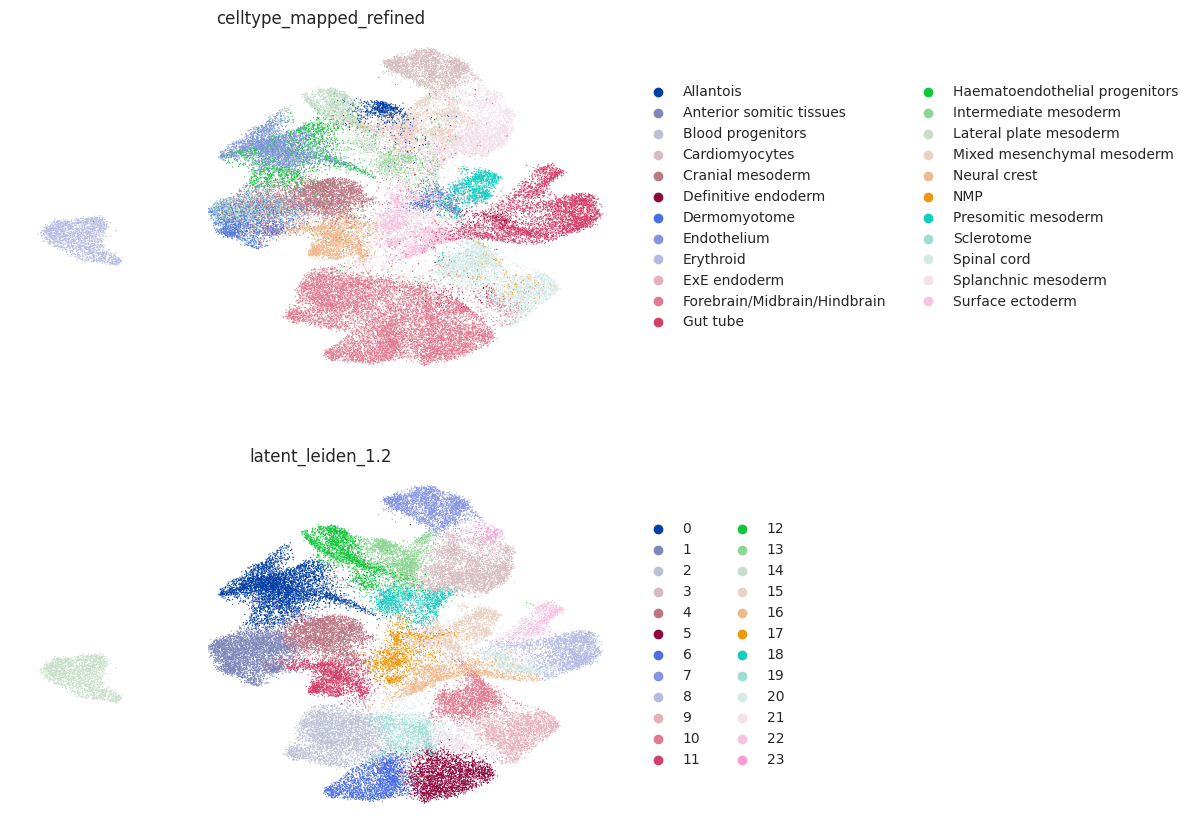

In [13]:
sc.pl.umap(model.adata, color=['celltype_mapped_refined', latent_cluster_key],
           show=True, wspace=0.35, size=3, frameon=False, ncols=1)

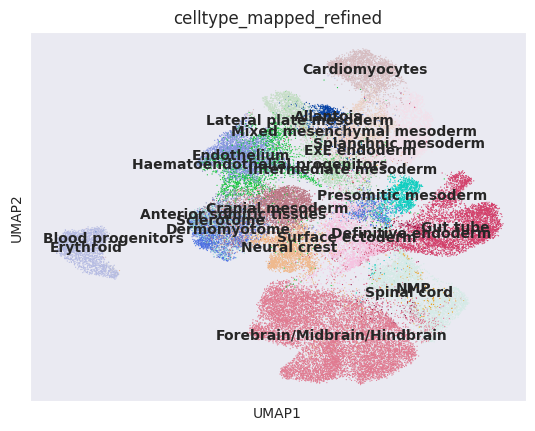

In [14]:
## celltype
sc.pl.umap(model.adata, color=[ 'celltype_mapped_refined'], ncols=3,
           wspace=0.5, show=True, legend_loc='on data', size=3)

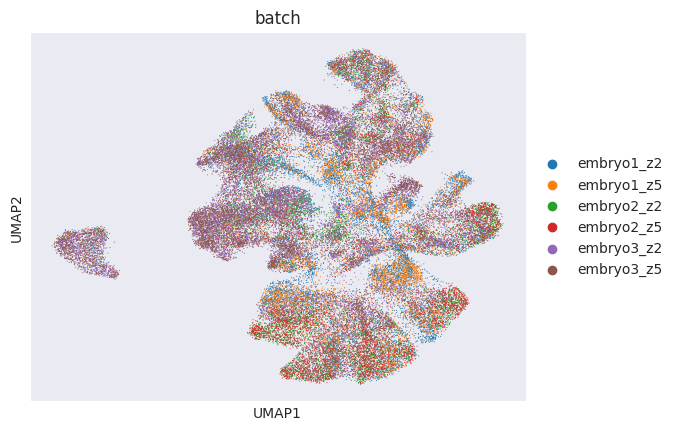

In [15]:
## batch information
sc.pl.umap(model.adata, color=['batch'], show=True)

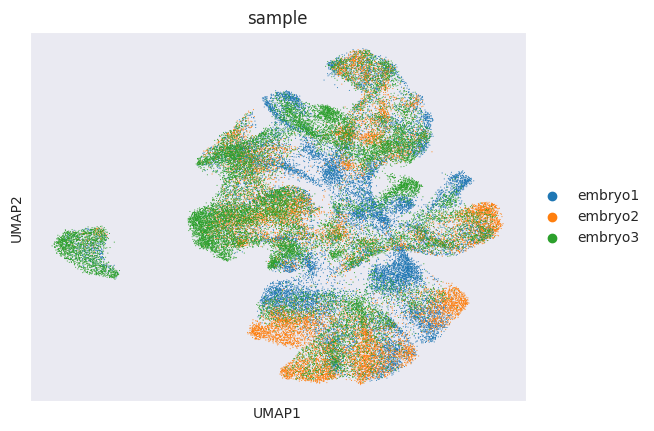

In [16]:
## sample information
sc.pl.umap(model.adata, color=['sample'], ncols=3,
           wspace=0.5, show=True)

scanpy==1.10.3 anndata==0.10.8 umap==0.5.7 numpy==1.26.4 scipy==1.13.1 pandas==2.2.3 scikit-learn==1.5.2 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


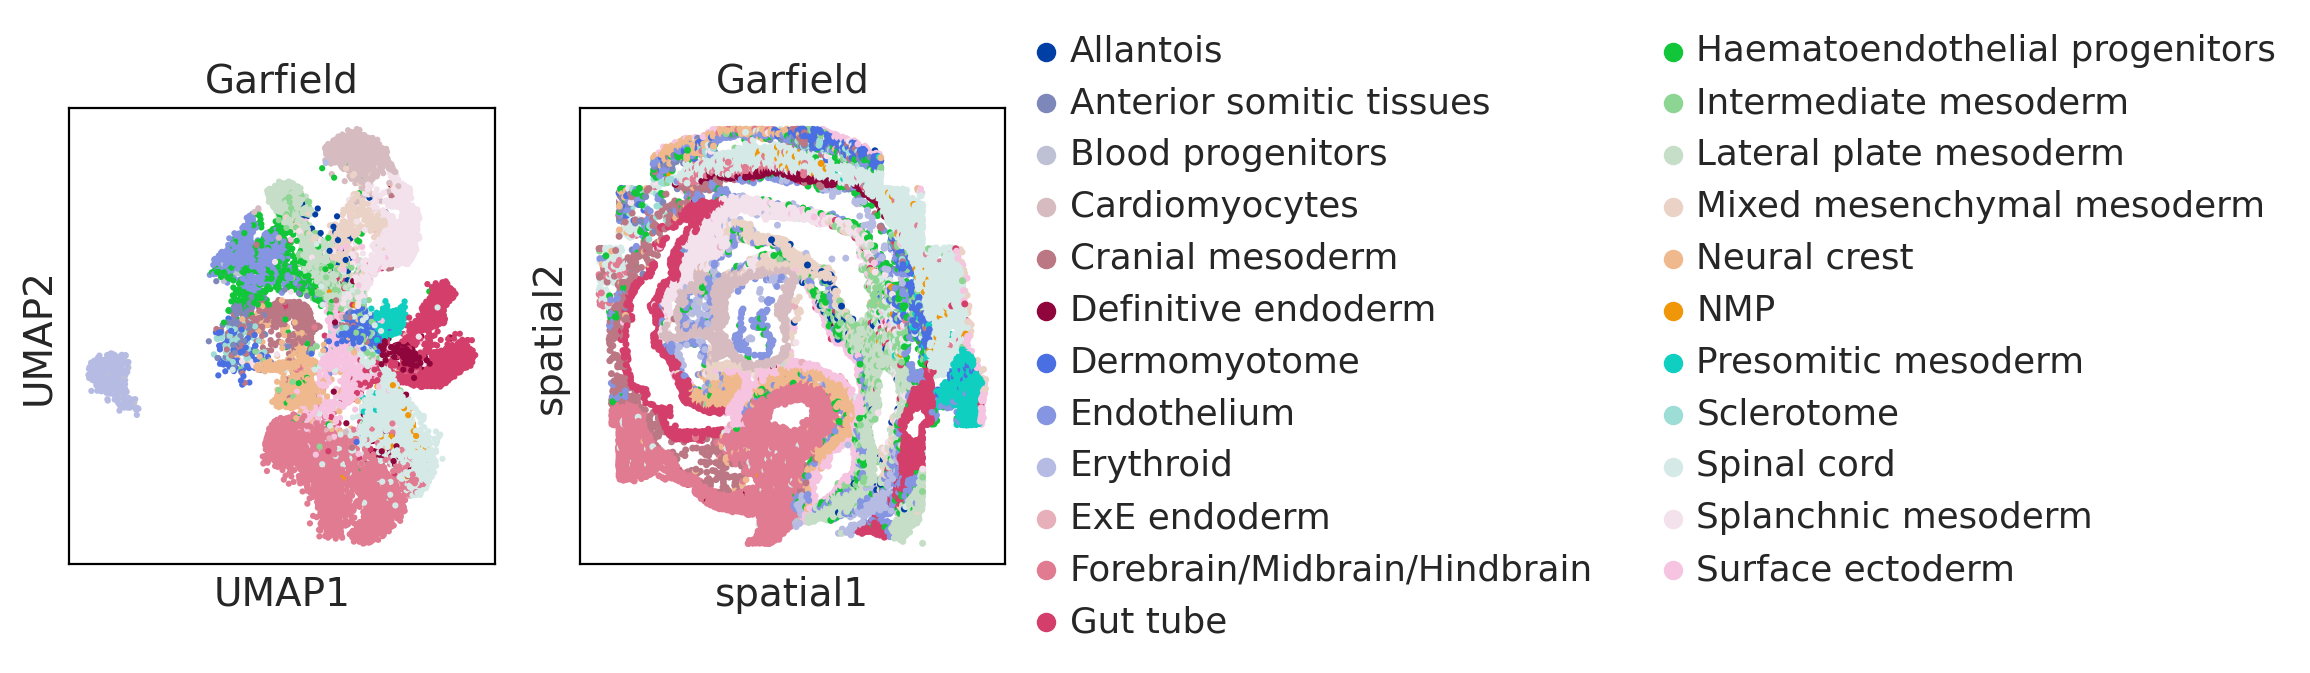

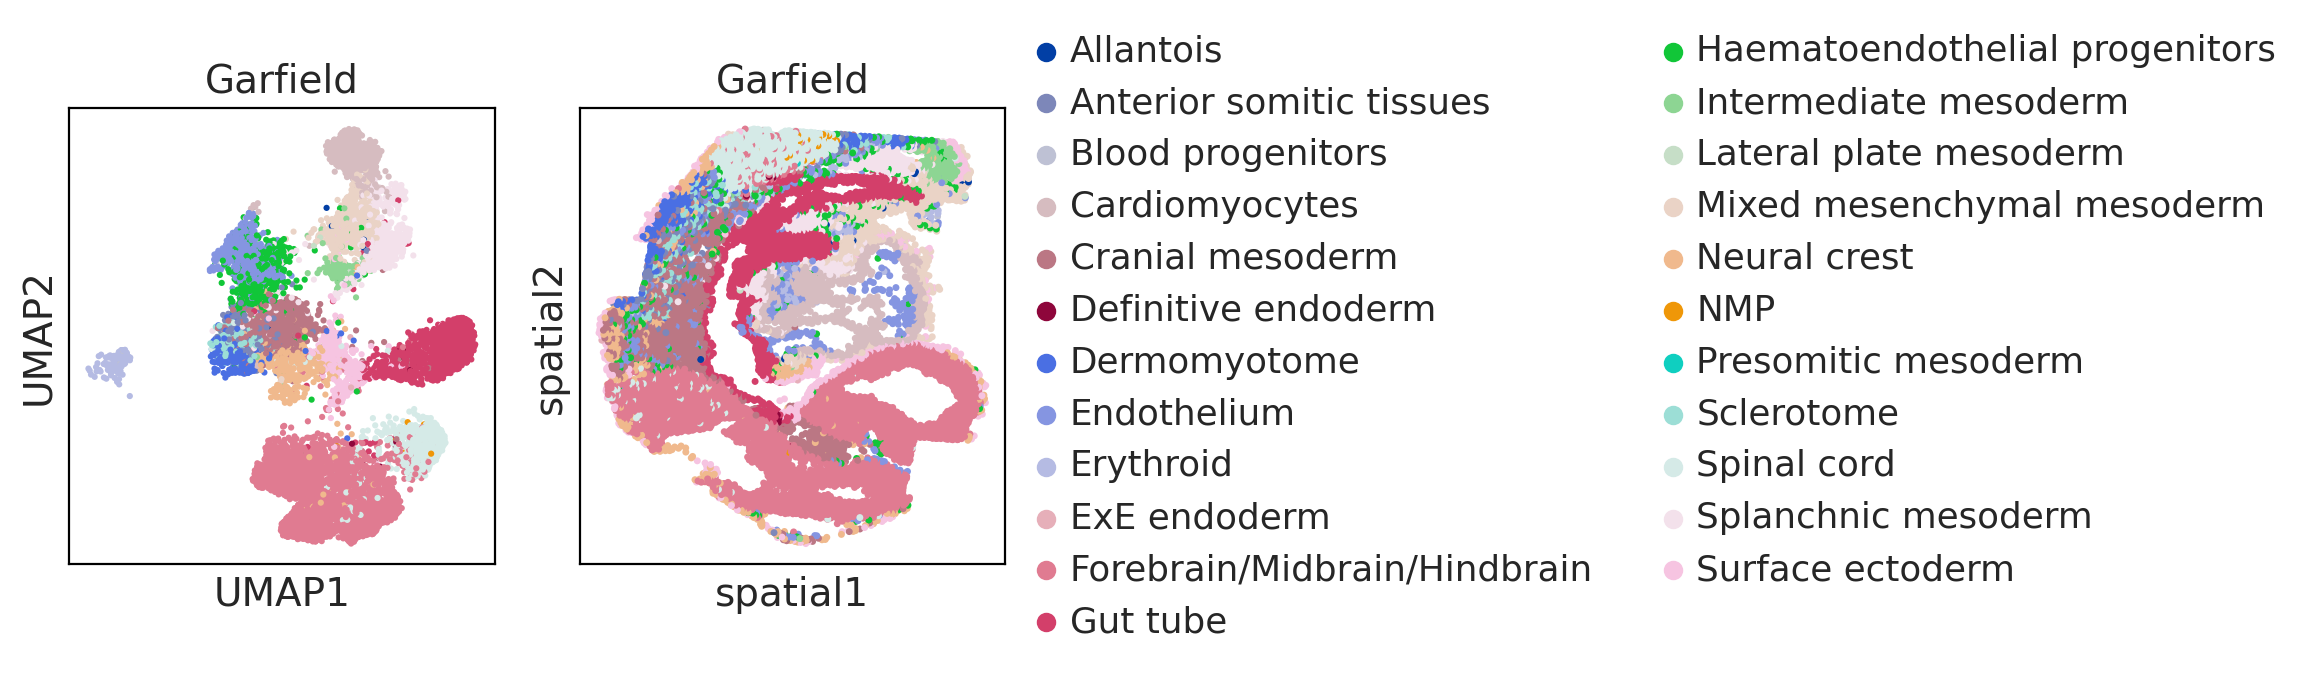

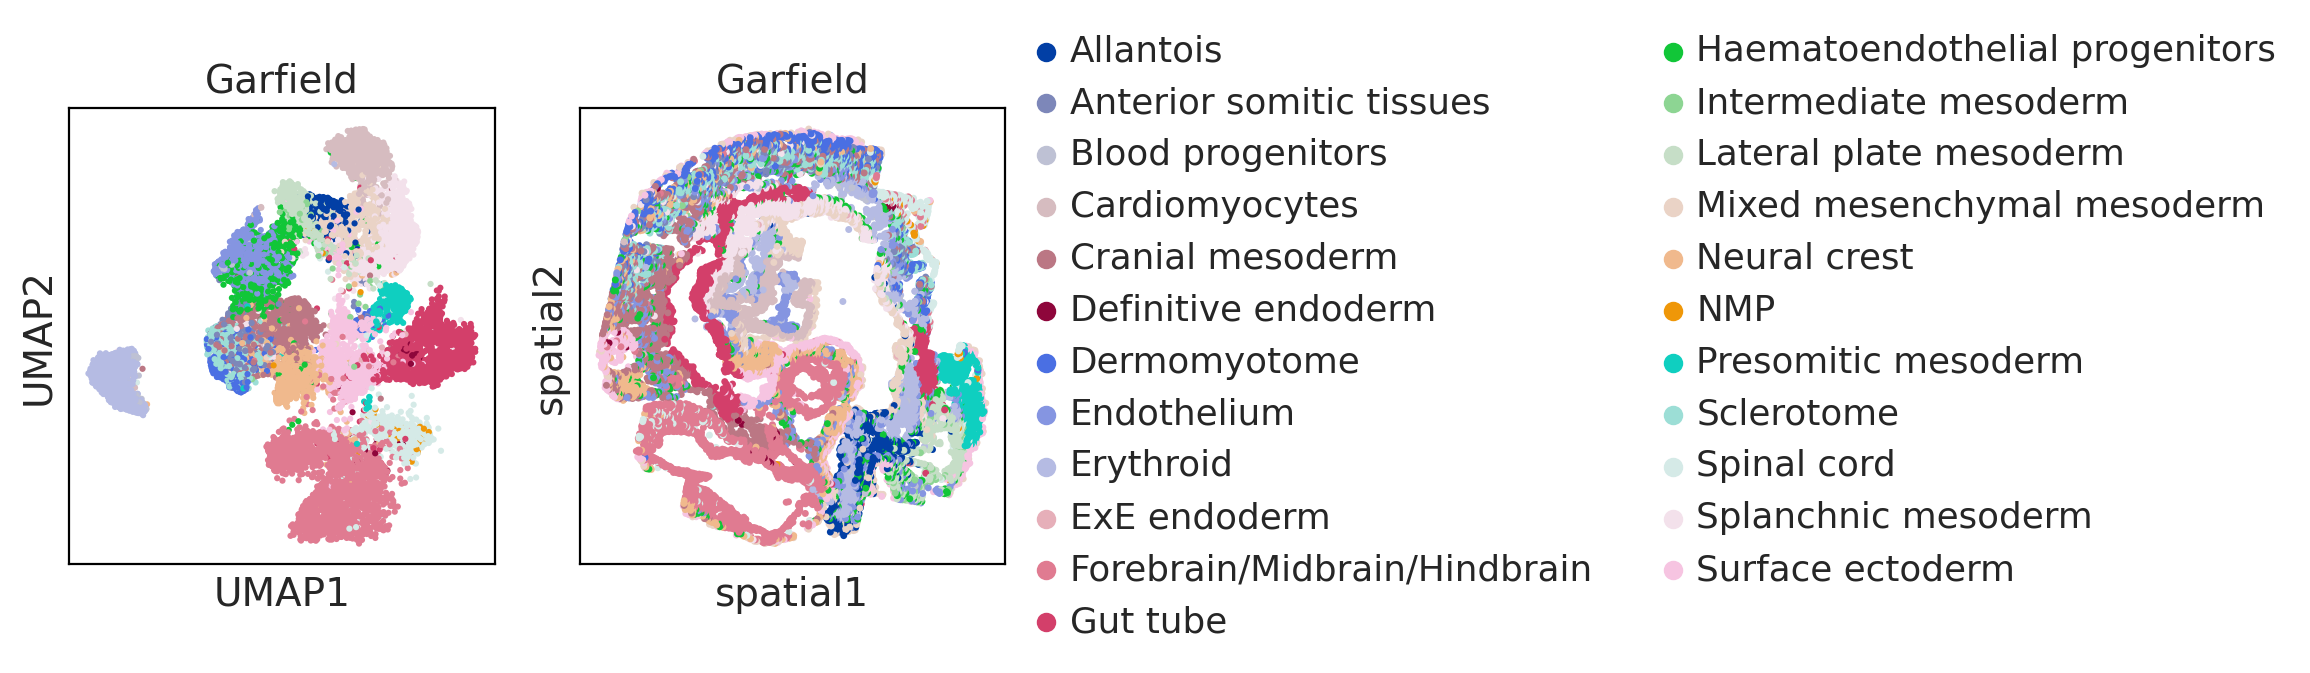

In [30]:
### Display spatial location distribution by sample
# import squidpy as sq
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, facecolor='white')

batch_indeces = list(model.adata.obs['sample'].unique())
for batch_idx in batch_indeces:
    tmp = model.adata[model.adata.obs['sample'] == batch_idx, ]

    # visualization
    import matplotlib.pyplot as plt
    fig, ax_list = plt.subplots(1, 2, figsize=(6, 3))
    sc.pl.umap(tmp, color=cell_type_key, ax=ax_list[0], title='Garfield',
               s=20, show=False,legend_loc=None)
    sc.pl.embedding(tmp, basis='spatial', color=cell_type_key, ax=ax_list[1],
                    title='Garfield', s=25, show=False)

    plt.tight_layout(w_pad=0.3)
    plt.show()

    # Visualize cell-level annotated data in physical space
    # sq.pl.spatial_scatter(tmp, color=cell_type_key, shape=None, figsize=(12, 12))
    # sq.pl.spatial_scatter(tmp, color=latent_cluster_key, shape=None, figsize=(12, 12))

In [31]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Model saved successfully using pickle at /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_embryo/model/attr.pkl


In [3]:
import re

from matplotlib import pyplot as plt
import matplotlib
matplotlib.use("Agg") #使用非交互式的后端生成图像文件

def pic(pdf):
    searchObj = re.search( r'(.*).pdf', pdf)
    png = f"{searchObj.group(1)}.png"
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, bbox_inches="tight", dpi=300)
    plt.close()

In [5]:
workdir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_embryo'
model_folder_path = f"{workdir}/model"

adata = sc.read_h5ad(os.path.join(model_folder_path, "adata_ref.h5ad"))
adata

AnnData object with n_obs × n_vars = 52568 × 351
    obs: 'Area', 'celltype_mapped_refined', 'sample', 'batch', 'slice_name', 'n_genes', 'latent_leiden_1.2'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'batch_colors', 'celltype_mapped_refined_colors', 'garfield_latent', 'hvg', 'latent_leiden_1.2', 'latent_leiden_1.2_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'feat', 'garfield_latent', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'distances', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities'

In [8]:
latent_leiden_resolution = 1.2
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"
sc.pl.umap(adata, color=['celltype_mapped_refined', latent_cluster_key],
           show=True, wspace=0.35, size=3, frameon=False, ncols=1)
pic(os.path.join(workdir, "dimplot_celltype.pdf"))

In [10]:
## celltype
sc.pl.umap(adata, color=[ 'celltype_mapped_refined'], ncols=3,
           wspace=0.5, show=True, legend_loc='on data', size=3)
pic(os.path.join(workdir, "dimplot_celltype_ondata.pdf"))

In [11]:
## batch information
sc.pl.umap(adata, color=['batch'], show=True)
pic(os.path.join(workdir, "dimplot_batch.pdf"))

In [12]:
## sample information
sc.pl.umap(adata, color=['sample'], ncols=3,
           wspace=0.5, show=True)
pic(os.path.join(workdir, "dimplot_sample.pdf"))

In [15]:
### Display spatial location distribution by sample
# import squidpy as sq
cell_type_key = "celltype_mapped_refined"

# sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, facecolor='white')

batch_indeces = list(adata.obs['sample'].unique())
for batch_idx in batch_indeces:
    tmp = adata[adata.obs['sample'] == batch_idx, ]

    # visualization
    import matplotlib.pyplot as plt
    fig, ax_list = plt.subplots(1, 2, figsize=(6, 3))
    sc.pl.umap(tmp, color=cell_type_key, ax=ax_list[0], title='Garfield',
               s=20, show=False,legend_loc=None)
    sc.pl.embedding(tmp, basis='spatial', color=cell_type_key, ax=ax_list[1],
                    title='Garfield', s=25, show=False)

    plt.tight_layout(w_pad=0.3)
    # plt.show()
    pic(os.path.join(workdir, f"spatial_plot_celltype-{batch_idx}.pdf"))

    # Visualize cell-level annotated data in physical space
    # sq.pl.spatial_scatter(tmp, color=cell_type_key, shape=None, figsize=(12, 12))
    # sq.pl.spatial_scatter(tmp, color=latent_cluster_key, shape=None, figsize=(12, 12))